In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob
import sklearn as sk
# D -> A


In [15]:
data_path = r"..\data\data_2358.csv" if os.name == "nt" else "../data/data_2358.csv"

if not os.path.exists(data_path):
    matches = glob.glob("**/data_2358.csv", recursive=True)
    if matches:
        data_path = matches[0]
    else:
        for root, _, files in os.walk("."):
            if "data_2358.csv" in files:
                data_path = os.path.join(root, "data_2358.csv")
                break

if not os.path.exists(data_path):
    raise FileNotFoundError(
        "data_2358.csv not found. Place the file in the notebook directory or specify the correct path."
    )

df = pd.read_csv(data_path)
print(f"Loaded data from: {data_path}")
df = df.iloc[:, 1:]  # Behold alt fra kolonne 1 og fremefter

Loaded data from: ../data/data_2358.csv


In [155]:
data_path_int_nega = r"..\data\-2a.csv" if os.name == "nt" else "../data/-2a.csv"
data_path_int_posa = r"..\data\2a.csv" if os.name == "nt" else "../data/2a.csv"

df_int_nega = pd.read_csv(data_path_int_nega)
df_int_posa = pd.read_csv(data_path_int_posa)
df_int_nega = df_int_nega.iloc[:, 1:]  # Behold alt fra kolonne 1 og fremefter
df_int_posa = df_int_posa.iloc[:, 1:]  # Behold alt fra kolonne 1 og fremefter

def normalize_columns(df):
    numeric_cols = df.select_dtypes(include=np.number).columns
    df[numeric_cols] = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std()
    return df
df_norm = df.copy()
df_int_nega_norm = df_int_nega.copy()
df_norm = normalize_columns(df_norm)
df_int_nega_norm = normalize_columns(df_int_nega_norm)
df_int_posa_norm = df_int_posa.copy()
df_int_posa_norm = normalize_columns(df_int_posa_norm)
# data_path_int_negd = r"..\data\-2d.csv" if os.name == "nt" else "../data/-2d.csv"
data_path_int_posd = r"..\data\2d.csv" if os.name == "nt" else "../data/2d.csv"
df_int_posd = pd.read_csv(data_path_int_posd)
df_int_posd = df_int_posd.iloc[:, 1:]  # Behold alt fra kolonne 1 og fremefter
df_int_posd_norm = df_int_posd.copy()
df_int_posd_norm = normalize_columns(df_int_posd_norm)

In [156]:
def MeanVariance(df):
    mean = df.mean()
    variance = df.var()
    return mean, variance
mean, variance = MeanVariance(df)
print("Mean:\n", mean)
print("\nVariance:\n", variance)
Mean, Variance = MeanVariance(df_int_posd)
print("\nIntervention Data:")
print("Mean:\n", Mean)
print("\nVariance:\n", Variance)


Mean:
 A    6.991572
B    4.140744
C   -0.130260
D   -1.128586
E   -1.149833
F    1.066195
dtype: float64

Variance:
 A    98.086601
B    27.103203
C     2.179402
D     5.260365
E     1.280953
F     3.503626
dtype: float64

Intervention Data:
Mean:
 A    4.401499
B    3.986295
C    0.096422
D    2.000000
E   -0.711459
F    0.875677
dtype: float64

Variance:
 A     0.657510
B    25.914808
C     1.781098
D     0.000000
E     2.684897
F     4.039415
dtype: float64


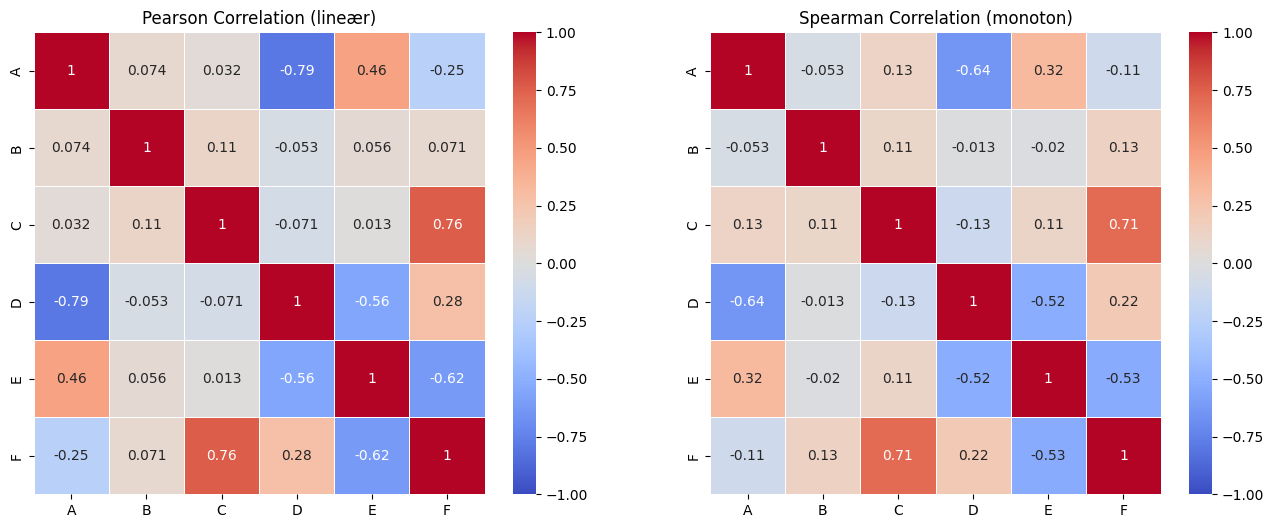

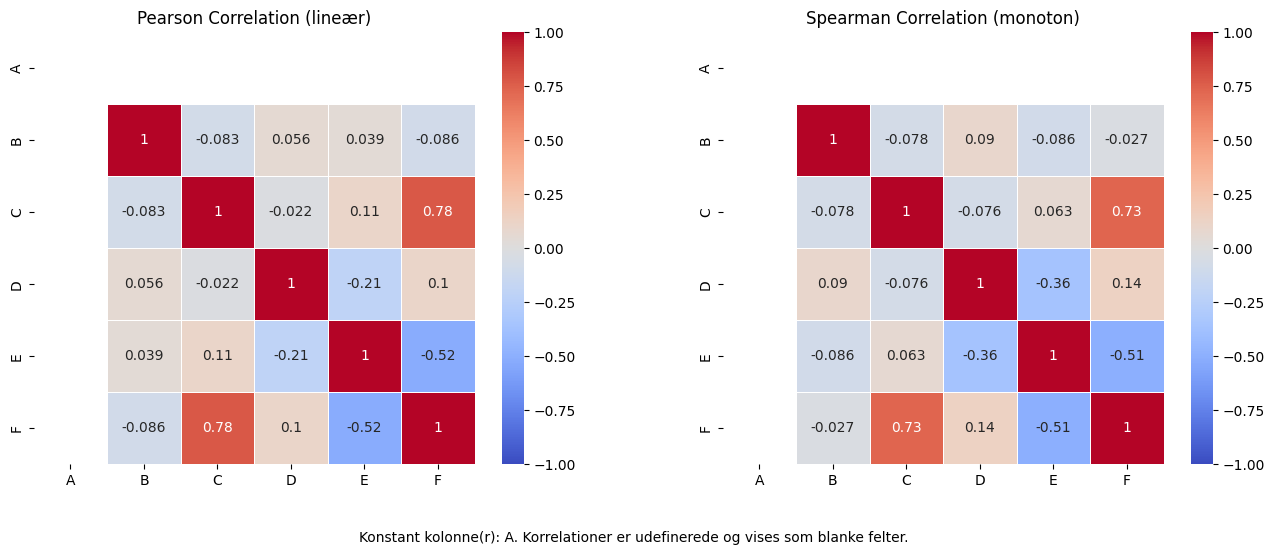

In [18]:
def compare_correlations(df, reference_columns=None):
    """Plot Pearson and Spearman correlations side by side"""
    numeric_df = df.select_dtypes(include=np.number).copy()
    if reference_columns is None:
        reference_columns = numeric_df.columns.tolist()
    pearson_corr = numeric_df.corr(method='pearson').reindex(index=reference_columns, columns=reference_columns)
    spearman_corr = numeric_df.corr(method='spearman').reindex(index=reference_columns, columns=reference_columns)
    constant_columns = [col for col in reference_columns if numeric_df[col].nunique(dropna=True) <= 1 if col in numeric_df.columns]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pearson
    sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title("Pearson Correlation (lineær)", fontsize=12)
    
    # Spearman
    sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title("Spearman Correlation (monoton)", fontsize=12)
    if constant_columns:
        fig.subplots_adjust(bottom=0.16, wspace=0.25)
        fig.text(0.5, 0.03, f"Konstant kolonne(r): {', '.join(constant_columns)}. Korrelationer er udefinerede og vises som blanke felter.", ha='center', fontsize=10)
    
    plt.show()

common_columns = df.select_dtypes(include=np.number).columns.tolist()
compare_correlations(df, reference_columns=common_columns)
compare_correlations(df_int, reference_columns=common_columns)

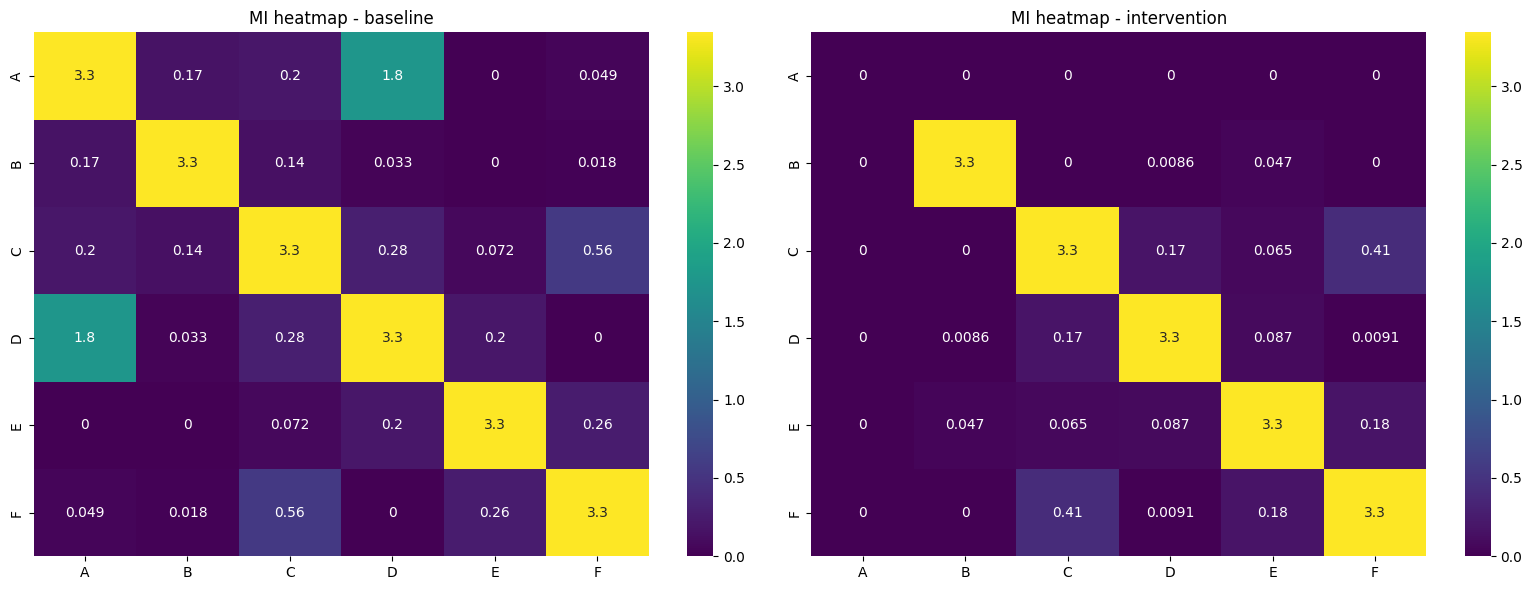

In [19]:
from sklearn.feature_selection import mutual_info_regression

def calculate_mi_matrix(df):
    variables = df.columns
    mi_matrix = pd.DataFrame(index=variables, columns=variables)
    
    for i in variables:
        for j in variables:
            # Vi beregner MI mellem variabel i og j
            # Reshape er nødvendig for sklearn
            mi = mutual_info_regression(df[[i]], df[j], random_state=42)
            mi_matrix.loc[i, j] = mi[0]
            
    return mi_matrix.astype(float)

# Kør den på jeres baseline data
mi_results = calculate_mi_matrix(df)
mi_int_results = calculate_mi_matrix(df_int)

common_columns = df.columns.tolist()
mi_results = mi_results.reindex(index=common_columns, columns=common_columns)
mi_int_results = mi_int_results.reindex(index=common_columns, columns=common_columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(mi_results, annot=True, cmap="viridis", ax=axes[0])
axes[0].set_title("MI heatmap - baseline")
sns.heatmap(mi_int_results, annot=True, cmap="viridis", ax=axes[1])
axes[1].set_title("MI heatmap - intervention")
plt.tight_layout()
plt.show()

Loaded intervention data from: ..\data\-2a.csv


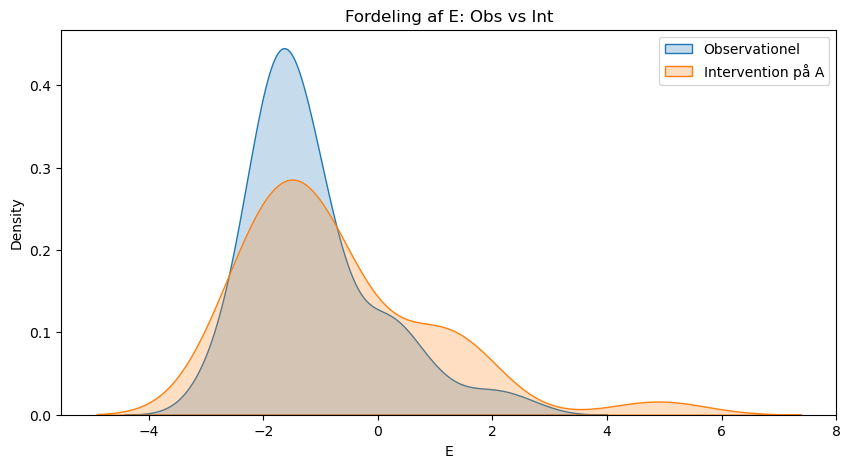

In [164]:
def check_confounder(obs_df, int_df_a, var_target='B'):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(obs_df[var_target], label='Observationel', fill=True)
    sns.kdeplot(int_df_a[var_target], label=f'Intervention på A', fill=True)
    plt.legend()
    plt.title(f"Fordeling af {var_target}: Obs vs Int")
    plt.show()

data_path_int = r"..\data\-2a.csv" if os.name == "nt" else "../data/-2a.csv"
df_int = pd.read_csv(data_path_int)
print(f"Loaded intervention data from: {data_path_int}")


check_confounder(df, df_int_posd, var_target='E')

In [168]:
def estimate_ace(df_high, df_low, target_var):
    """
    Estimate the Average Causal Effect (ACE) of a treatment variable on a target variable.
    
    Parameters:
    df_high (pd.DataFrame): DataFrame with high treatment values
    df_low (pd.DataFrame): DataFrame with low treatment values
    target_var (str): Name of the target variable
    # Average Causal Effect (ACE) estimation

    # ACE > 0: X har en positiv effekt på Y (X op -> Y op).
    # ACE < 0: X har en negativ effekt på Y (X op -> Y ned).
    # ACE = 0: X har ingen kausal effekt på Y 
    
    Returns:
    float: The estimated ACE
    """     
    # E[Y | do(X=2)] - E[Y | do(X=-2)] divideret med afstanden i X (4)
    ace = (df_high[target_var].mean() - df_low[target_var].mean()) / 4
    return ace

data_path_high = r"..\data\2a.csv" if os.name == "nt" else "../data/2a.csv"
data_path_low = r"..\data\-2a.csv" if os.name == "nt" else "../data/-2a.csv"
df_high = df_int_posa_norm

df_low = df_int_nega_norm

targets = [c for c in df_high.select_dtypes(include=np.number).columns if c != 'A' and not str(c).startswith('Unnamed')]
ace_results = {}
for t in targets:
    ace_results[t] = estimate_ace(df_high, df_low, target_var=t)

# keep ace_estimate for compatibility with the existing print
ace_estimate = ace_results.get('C', next(iter(ace_results.values())) if ace_results else np.nan)

for t, v in ace_results.items():
    print(f"Estimated ACE of A on {t}: {v:.3f}")

Estimated ACE of A on B: -0.000
Estimated ACE of A on C: -0.000
Estimated ACE of A on D: 0.000
Estimated ACE of A on E: 0.000
Estimated ACE of A on F: 0.000


In [167]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


def estimate_causal_effect_hybrid(df, treatment_col, outcome_col, confounder_cols=None, random_state=42):
    """
    Estimerer en kausal effekt med en hybrid/double-machine-learning stil:
    - fleksibel model til at fange lineære og ikke-lineære mønstre i confounders
    - residualisering af både treatment og outcome
    - lineær regression på residualerne for at få treatment-effekten

    Dette er mere fleksibelt end ren lineær regression, men er stadig afhængigt af
    antagelsen om, at de vigtigste confounders er med i data.
    """
    if confounder_cols is None:
        confounder_cols = [c for c in df.columns if c not in [treatment_col, outcome_col]]

    use_cols = [treatment_col, outcome_col] + confounder_cols
    data = df[use_cols].dropna().copy()

    if len(confounder_cols) == 0:
        raise ValueError("Der skal være mindst én confounder-kolonne for denne metode.")

    X_conf = data[confounder_cols]
    t = data[treatment_col].to_numpy()
    y = data[outcome_col].to_numpy()

    # Fleksible modeller til at fange både lineære og ikke-lineære relationer
    y_model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        min_samples_leaf=5,
    )
    t_model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        min_samples_leaf=5,
    )

    y_model.fit(X_conf, y)
    t_model.fit(X_conf, t)

    y_residual = y - y_model.predict(X_conf)
    t_residual = t - t_model.predict(X_conf)

    final_model = LinearRegression()
    final_model.fit(t_residual.reshape(-1, 1), y_residual)

    return {
        "causal_effect": final_model.coef_[0],
        "intercept": final_model.intercept_,
        "outcome_model": y_model,
        "treatment_model": t_model,
        "final_model": final_model,
        "used_columns": use_cols,
    }


# Vælg selv hvilke kolonner der er treatment og outcome
# Eksempel: treatment_col = "..." og outcome_col = "..."
# Hvis du bare vil teste hurtigt, kan du bruge to numeriske kolonner
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) >= 2:
    treatment_col = numeric_cols[0] # 0 = 0, 1 = A, 2 = B, 3 = C, 4 = D
    outcome_col = numeric_cols[1]
    confounder_cols = [c for c in numeric_cols if c not in [treatment_col, outcome_col]]

    inverse_treatment_col = outcome_col
    inverse_outcome_col = treatment_col
    inverse_result = estimate_causal_effect_hybrid(df, inverse_treatment_col, inverse_outcome_col, confounder_cols)

    result = estimate_causal_effect_hybrid(df, treatment_col, outcome_col, confounder_cols)
    print(f"Treatment: {treatment_col}")
    print(f"Outcome: {outcome_col}")
    print(f"Estimeret hybrid kausal effekt: {result['causal_effect']:.4f}")

    print(f"\nInvers test (omvendt treatment og outcome):")
    print(f"Treatment: {inverse_treatment_col}")
    print(f"Outcome: {inverse_outcome_col}")
    print(f"Estimeret hybrid kausal effekt: {inverse_result['causal_effect']:.4f}")
else:
    print("Der skal være mindst to numeriske kolonner for at køre eksemplet.")


Treatment: A
Outcome: B
Estimeret hybrid kausal effekt: -0.0443

Invers test (omvendt treatment og outcome):
Treatment: B
Outcome: A
Estimeret hybrid kausal effekt: -0.0215


## C. Invarians-test (Invariant Causal Prediction)

Idéen er, at hvis en variabel virkelig er en årsag til en target `Y`, så bør sammenhængen mellem dem være mere stabil på tværs af forskellige miljøer eller interventioner.

- Hvis `Y` ændrer sig, når vi skifter miljø for en kandidatvariabel `X`, tyder det på en kausal relation.
- Hvis fordelingen af `Y` er nogenlunde den samme på tværs af miljøer for en variabel `Z`, er `Z` mindre sandsynligt en direkte årsag til `Y`.

Nedenfor er en enkel invarians-test, som sammenligner middelværdien af residualer på tværs af miljøer. Den er ikke en fuld ICP-implementering, men den giver en praktisk og let forståelig test i notebooken.

In [23]:
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression


def icp_invariance_test(df, target_col, cause_col, confounder_cols=None, env_col=None, n_env=3, alpha=0.05):
    """
    Enkel invarians-test inspireret af Invariant Causal Prediction.

    Idé:
    - Del data op i miljøer (environments)
    - Fit en model for target ud fra kandidat-variabler
    - Test om residualerne er ens på tværs af miljøer

    Hvis residualerne ikke ser forskellige ud mellem miljøerne, er relationen mere stabil.
    """
    if confounder_cols is None:
        confounder_cols = [c for c in df.columns if c not in [target_col, cause_col, env_col]]

    cols = [target_col, cause_col] + confounder_cols
    if env_col is not None:
        cols.append(env_col)

    data = df[cols].dropna().copy()

    if env_col is None:
        # Skab kunstige miljøer ved at opdele cause_col i kvantiler
        data["environment"] = pd.qcut(data[cause_col], q=n_env, labels=False, duplicates="drop")
        env_col = "environment"

    X = data[[cause_col] + confounder_cols]
    y = data[target_col]
    env = data[env_col]

    model = LinearRegression()
    model.fit(X, y)
    residuals = y - model.predict(X)

    groups = [residuals[env == g] for g in sorted(env.unique())]
    groups = [g for g in groups if len(g) > 1]

    if len(groups) < 2:
        raise ValueError("Der skal være mindst to miljøer med mere end én observation hver.")

    stat, p_value = f_oneway(*groups)
    invariant = p_value > alpha

    return {
        "invariant": invariant,
        "p_value": p_value,
        "statistic": stat,
        "residual_model": model,
        "used_columns": cols,
    }


# Eksempel: brug første numeriske kolonne som kandidat-årsag og anden som target
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) >= 2:
    cause_col = numeric_cols[0]
    target_col = numeric_cols[1]
    confounder_cols = [c for c in numeric_cols if c not in [cause_col, target_col]]

    icp_result = icp_invariance_test(df, target_col, cause_col, confounder_cols=confounder_cols)
    print(f"Cause candidate: {cause_col}")
    print(f"Target: {target_col}")
    print(f"Invariant relation: {icp_result['invariant']}")
    print(f"p-værdi: {icp_result['p_value']:.4f}")
else:
    print("Der skal være mindst to numeriske kolonner for at køre invarians-testen.")

Cause candidate: A
Target: B
Invariant relation: True
p-værdi: 0.5074


In [24]:
def kolmogorov_smirnov_test(df, col1, col2):
    from scipy.stats import ks_2samp
    data1 = df[col1].dropna()
    data2 = df[col2].dropna()
    stat, p_value = ks_2samp(data1, data2)
    return stat, p_value

# Eksempel: sammenlign fordelingen af to numeriske kolonner
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if len(numeric_cols) >= 2:
    col1 = numeric_cols[3]
    col2 = numeric_cols[4]
    stat, p_value = kolmogorov_smirnov_test(df, col1, col2)
    print(f"Kolmogorov-Smirnov test mellem {col1} og {col2}:")
    print(f"Statistic: {stat:.4f}, p-værdi: {p_value:.4f}")
else:
    print("Der skal være mindst to numeriske kolonner for at køre Kolmogorov-Smirnov testen.")


for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        col1 = numeric_cols[i]
        col2 = numeric_cols[j]
        stat, p_value = kolmogorov_smirnov_test(df, col1, col2)
        print(f"KS test mellem {col1} og {col2}: stat={stat:.4f}, p={p_value:.9f}")
# lav pværdi indikerer at de er fra forskellige fordelinger, høj p-værdi indikerer at de kunne være fra samme fordeling


Kolmogorov-Smirnov test mellem D og E:
Statistic: 0.2600, p-værdi: 0.0022
KS test mellem A og B: stat=0.2000, p=0.036384288
KS test mellem A og C: stat=0.6900, p=0.000000000
KS test mellem A og D: stat=0.6600, p=0.000000000
KS test mellem A og E: stat=0.8100, p=0.000000000
KS test mellem A og F: stat=0.4500, p=0.000000002
KS test mellem B og C: stat=0.5600, p=0.000000000
KS test mellem B og D: stat=0.6200, p=0.000000000
KS test mellem B og E: stat=0.8200, p=0.000000000
KS test mellem B og F: stat=0.3800, p=0.000000800
KS test mellem C og D: stat=0.3200, p=0.000062812
KS test mellem C og E: stat=0.5000, p=0.000000000
KS test mellem C og F: stat=0.4100, p=0.000000066
KS test mellem D og E: stat=0.2600, p=0.002219936
KS test mellem D og F: stat=0.4300, p=0.000000011
KS test mellem E og F: stat=0.6100, p=0.000000000


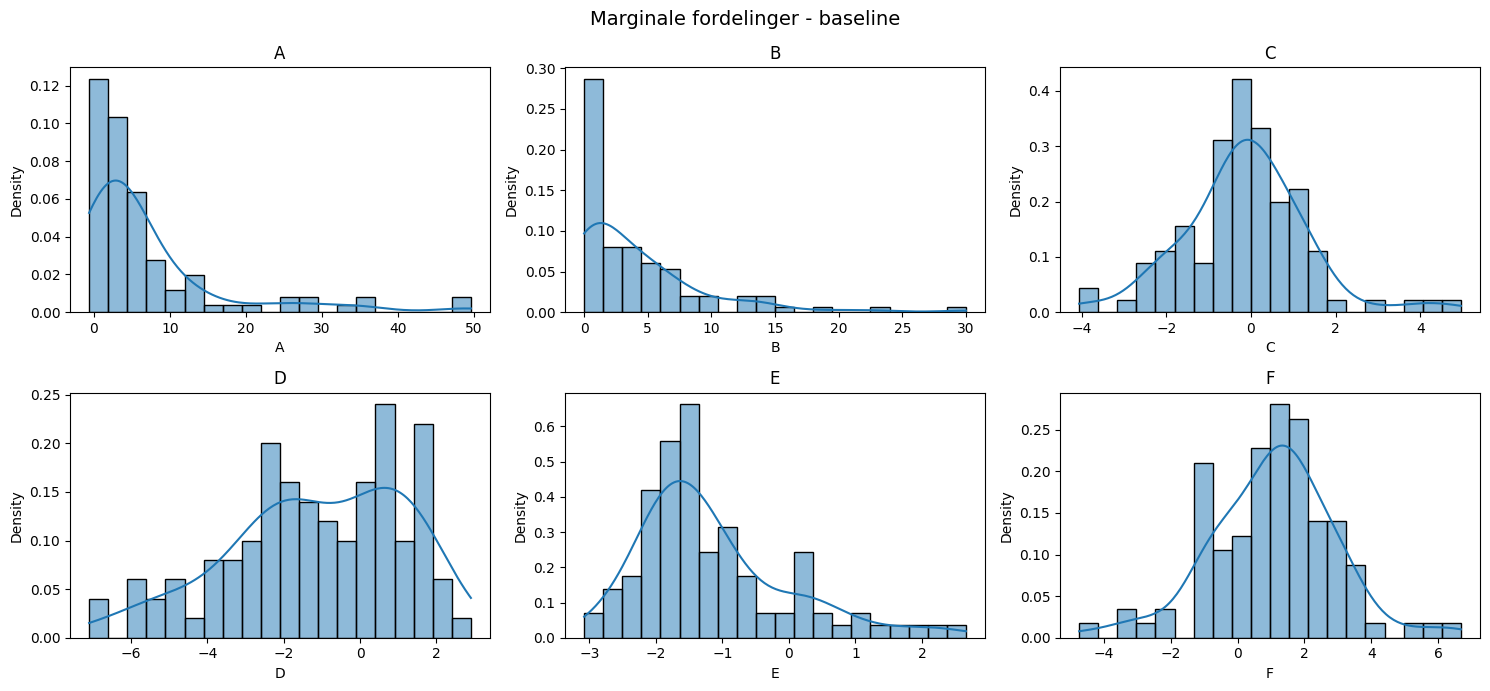

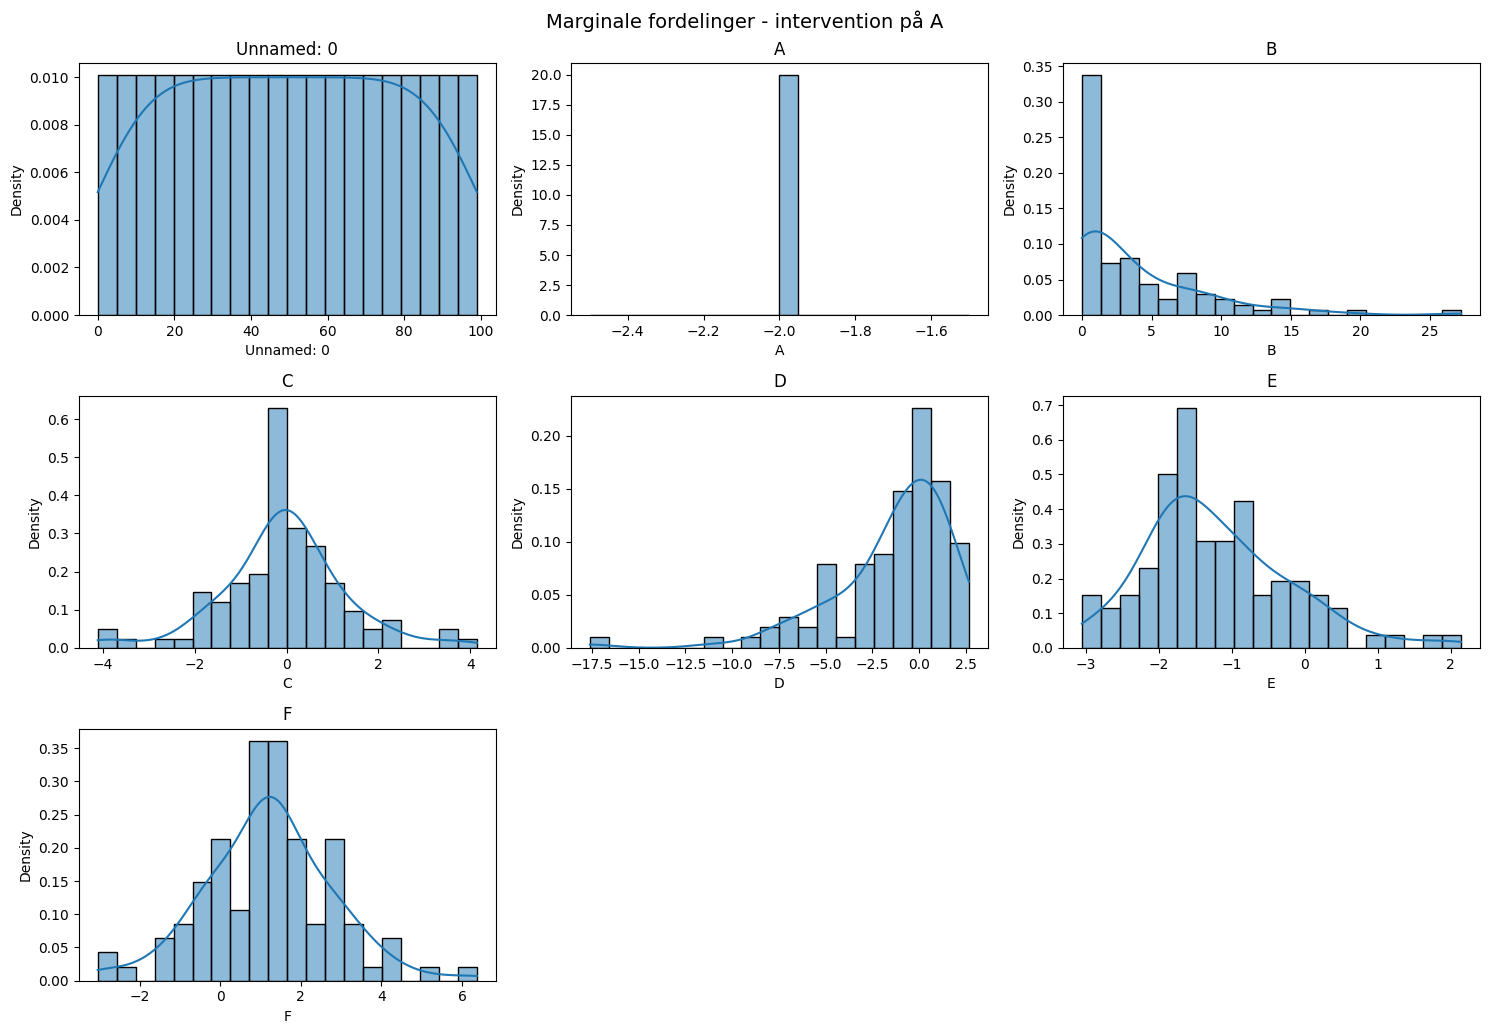

In [25]:
def plot_marginals(df, title):
    numeric_df = df.select_dtypes(include=np.number)
    columns = numeric_df.columns.tolist()
    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, columns):
        sns.histplot(numeric_df[col], kde=True, stat='density', bins=20, ax=ax)
        ax.set_title(col)

    for ax in axes[len(columns):]:
        ax.axis('off')

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()

plot_marginals(df, "Marginale fordelinger - baseline")
plot_marginals(df_int, "Marginale fordelinger - intervention på A")

# efter at have kigget på correlation, er marginalerne ofte mere informative for interventionen på A




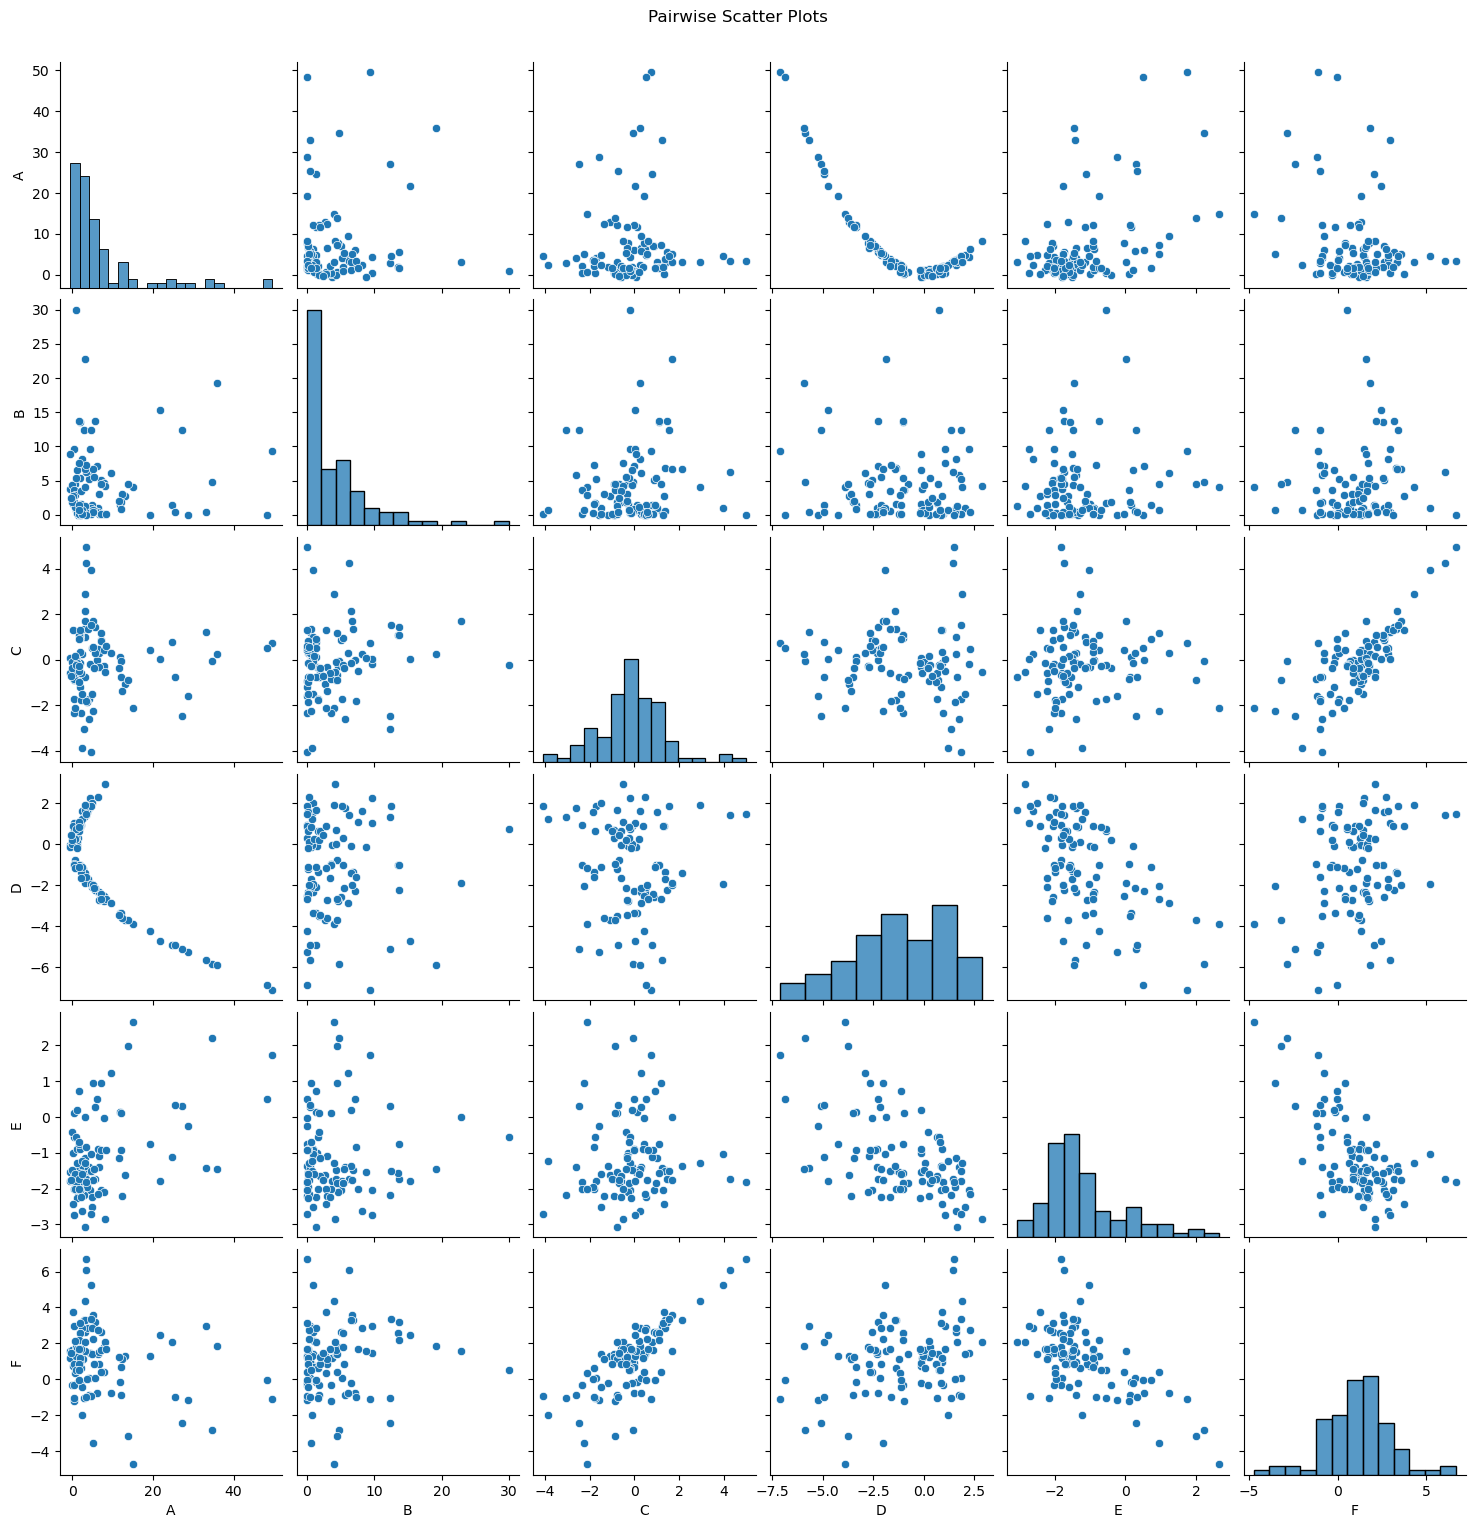

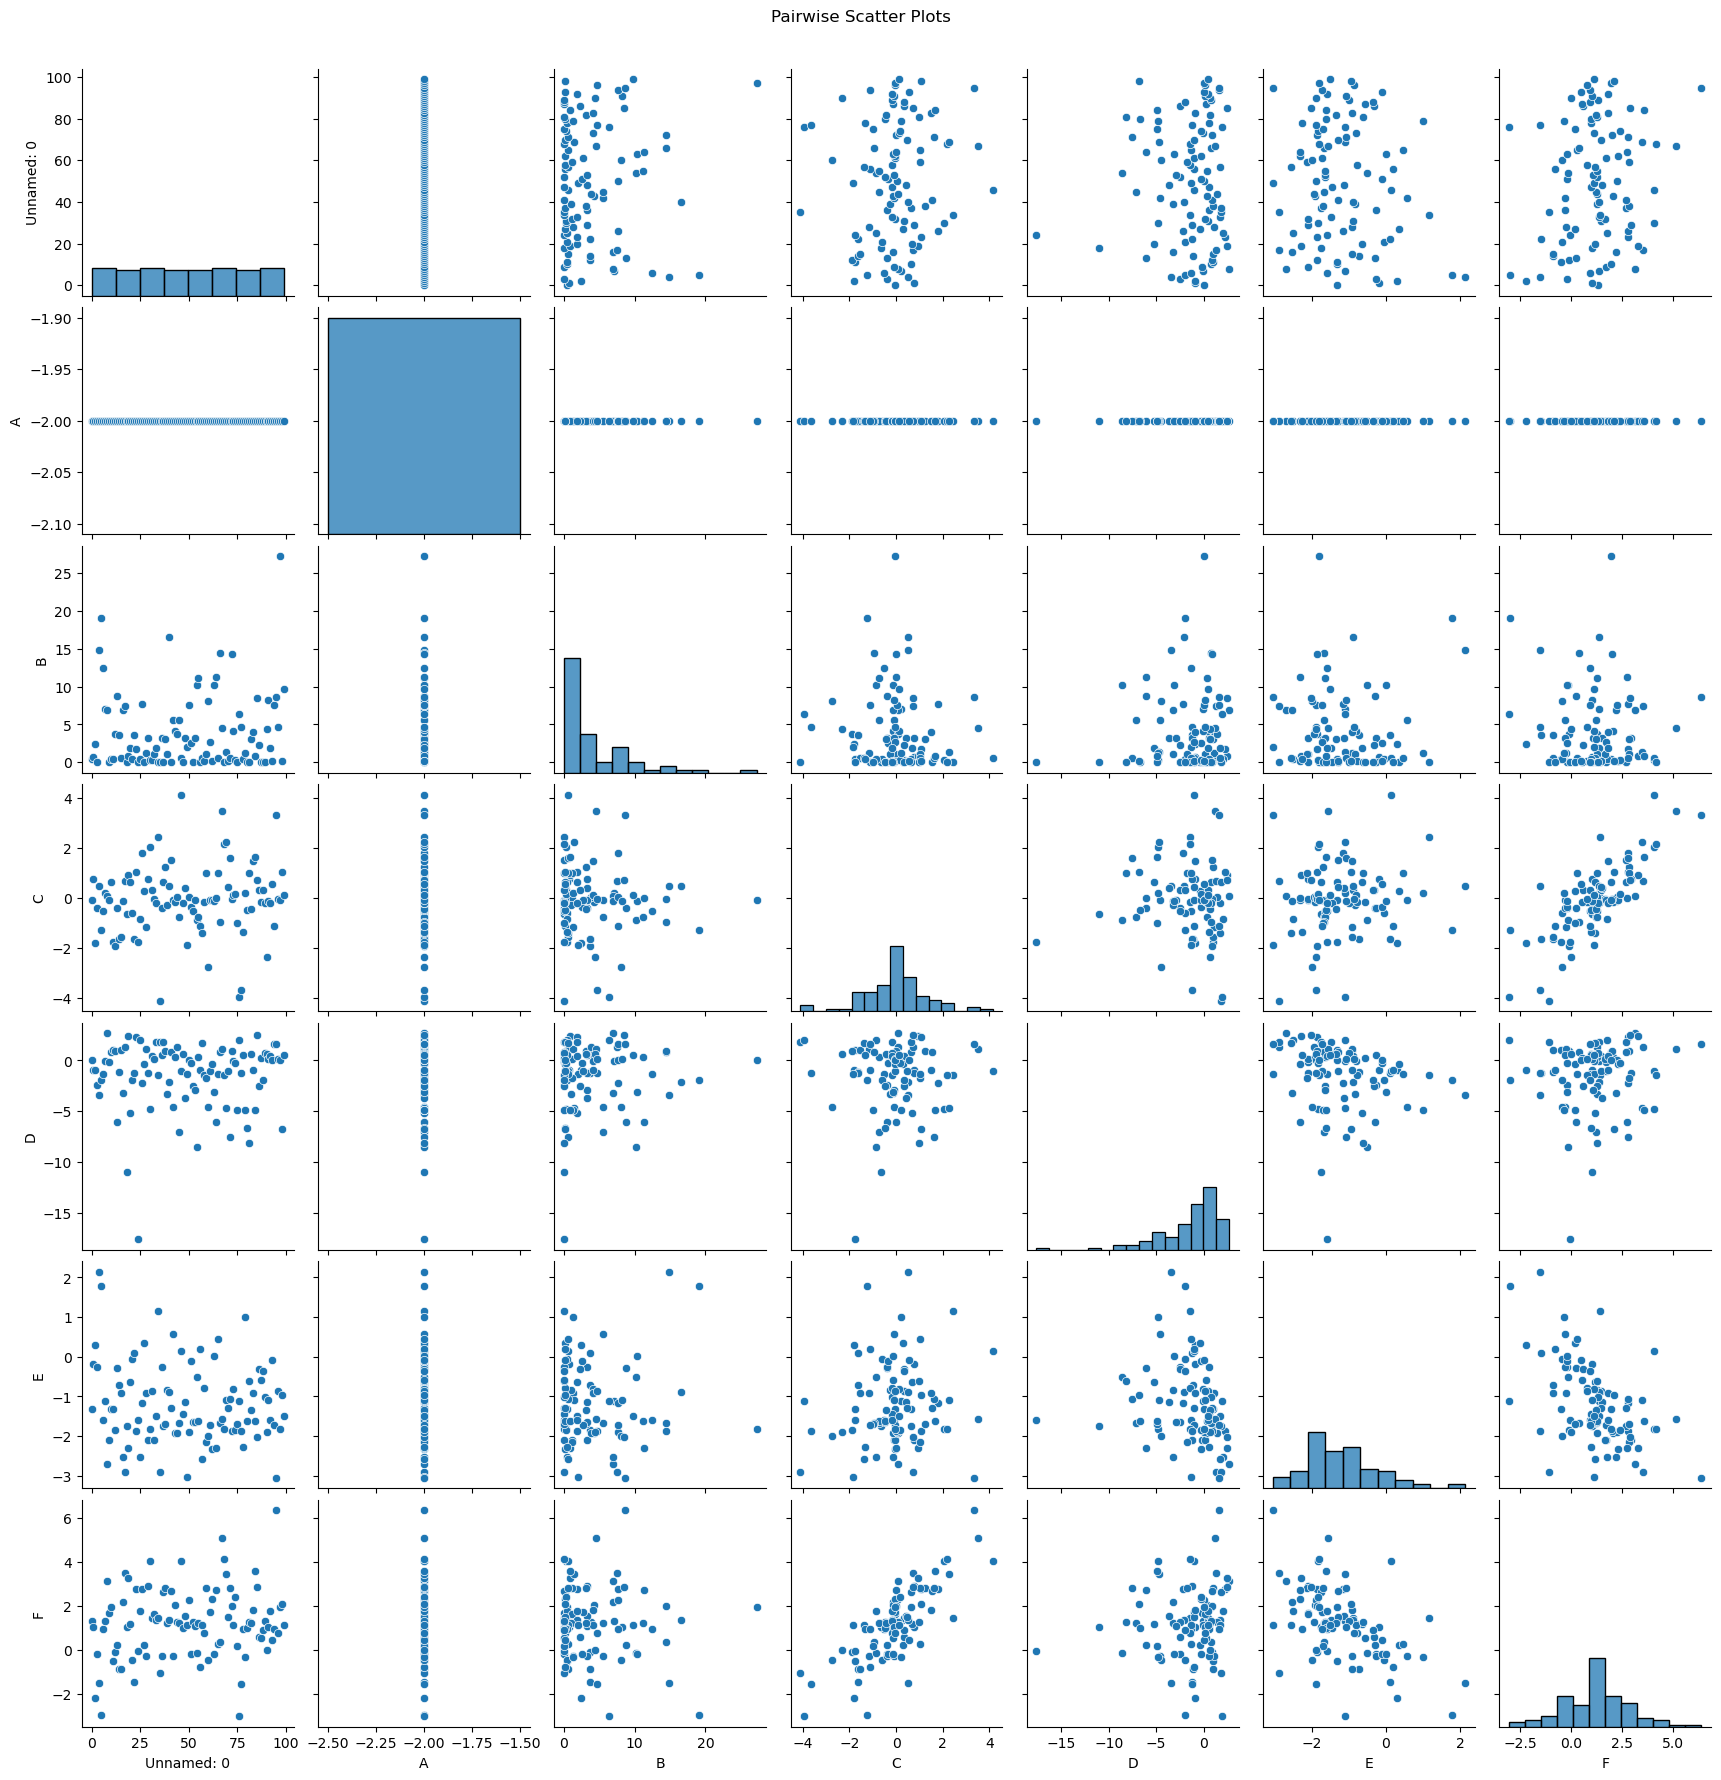

In [169]:
def pairwise_scatter(df):
    sns.pairplot(df)
    plt.suptitle("Pairwise Scatter Plots", y=1.02)
    plt.show()

pairwise_scatter(df)
pairwise_scatter(df_int)